# July mobile forecast — parameter sensitivity (round 1)

One-at-a-time local-slope probe of the July `glean_mobile` DAU forecast. From the
current mobile params (= `MobileModelConfig` defaults = June params), each of six
knobs is perturbed symmetrically by a small delta while the others stay at center,
so `(net(+δ) − net(−δ)) / 2δ` estimates the local slope of the **Dec-15 net vs June**
(ALL-MOBILE, plus-Iran, 28-day MA, with marketing `m` + headwind `h` applied).

- **Baseline (June):** 17,511,100 · **Target (+400k):** 17,911,100.
- Runs live in `results/<slug>/`; scored by `scripts/mobile_sensitivity.py`;
  produced by `scripts/mobile_grid_search.py`.

Deliverables: one sensitivity plot per variable, a knob-slope tornado, and a full
Prophet decomposition of the single all-level mobile model. Round 1 of an
iterative search — not a final config.


In [1]:
# [setup]
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Walk up to the repo root (where src/mozaic_daily lives) so the notebook runs
# regardless of the kernel's cwd.
REPO = Path.cwd()
while not (REPO / "src" / "mozaic_daily").exists() and REPO != REPO.parent:
    REPO = REPO.parent
for p in [REPO / "src", REPO / "scripts", REPO / "data-official/2026-06",
          REPO / "tooling/prophet_decompose"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import mobile_grid_search as g          # PARAM_GRID + slug/path helpers
from mobile_sensitivity import (
    all_mobile_daily, forecast_display_ma, apply_headwind, score_forecast,
    JUNE_BASELINE_MA28, TARGET_MA28, DEC15, FORECAST_START,
)

RESULTS_DIR = REPO / "research/param-scans/mobile-july/results"
PLOTS_DIR = REPO / "research/param-scans/mobile-july/plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = REPO / "research/param-scans/mobile-july/round1_results.csv"

results = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else None
print(f"baseline {JUNE_BASELINE_MA28:,.0f}   target {TARGET_MA28:,.0f}   (uplift +400,000)")
print("knobs:", [p[0] for p in g.PARAM_GRID])
if results is not None:
    print(f"round1_results.csv: {len(results)} rows")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


baseline 17,511,100   target 17,911,100   (uplift +400,000)
knobs: ['prophet_changepoint_prior_scale', 'prophet_changepoint_range', 'prophet_n_changepoints', 'prophet_recent_weeks', 'holiday_threshold', 'holiday_effect_floor']
round1_results.csv: 13 rows


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [load-runs]
# For the center config and each perturbation, load the adj-m ALL-MOBILE daily
# series, build the canonical seam MA, apply the headwind, and score at Dec-15.
def curve_and_score(parquet):
    daily = all_mobile_daily(pd.read_parquet(parquet))
    ma_hm = apply_headwind(forecast_display_ma(daily))   # adj-hm 28d-MA curve
    return ma_hm, score_forecast(parquet)

center_pq = g.adjm_parquet_for(g.slug_dir_for(RESULTS_DIR, {}))
center_curve, center_score = curve_and_score(center_pq)
print(f"center  Dec-15 net vs June: {center_score['net_vs_june']:+,.0f}   "
      f"(gap to +400k: {center_score['gap_to_target']:+,.0f})")

# RUNS[field] = {"center": (curve, score, value), "minus": (...), "plus": (...)}
RUNS = {}
for field, flag, center, minus, plus in g.PARAM_GRID:
    entry = {"center": (center_curve, center_score, center)}
    for direction, val in (("minus", minus), ("plus", plus)):
        pq = g.adjm_parquet_for(g.slug_dir_for(RESULTS_DIR, {field: val}))
        if pq.exists():
            curve, score = curve_and_score(pq)
            entry[direction] = (curve, score, val)
        else:
            entry[direction] = None
            print(f"  MISSING: {field} {direction} -> {pq.parent.name}")
    RUNS[field] = entry
print("loaded runs for:", list(RUNS.keys()))


center  Dec-15 net vs June: +286,862   (gap to +400k: +113,138)


loaded runs for: ['prophet_changepoint_prior_scale', 'prophet_changepoint_range', 'prophet_n_changepoints', 'prophet_recent_weeks', 'holiday_threshold', 'holiday_effect_floor']


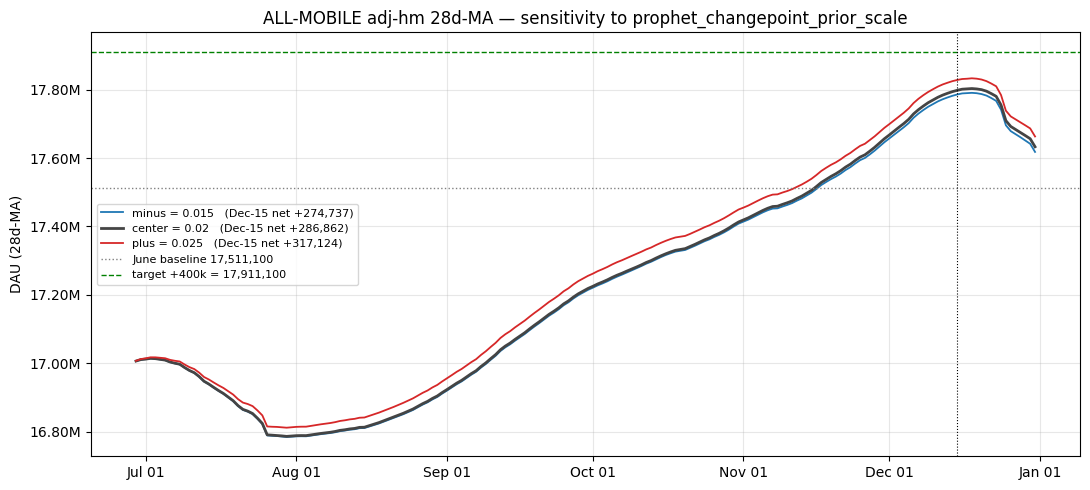

saved research/param-scans/mobile-july/plots/sensitivity_prophet_changepoint_prior_scale.png


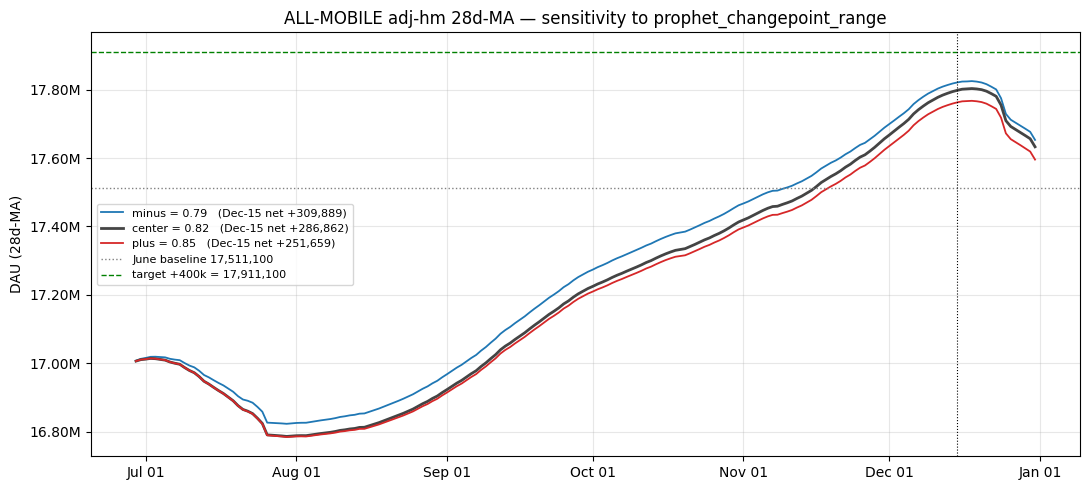

saved research/param-scans/mobile-july/plots/sensitivity_prophet_changepoint_range.png


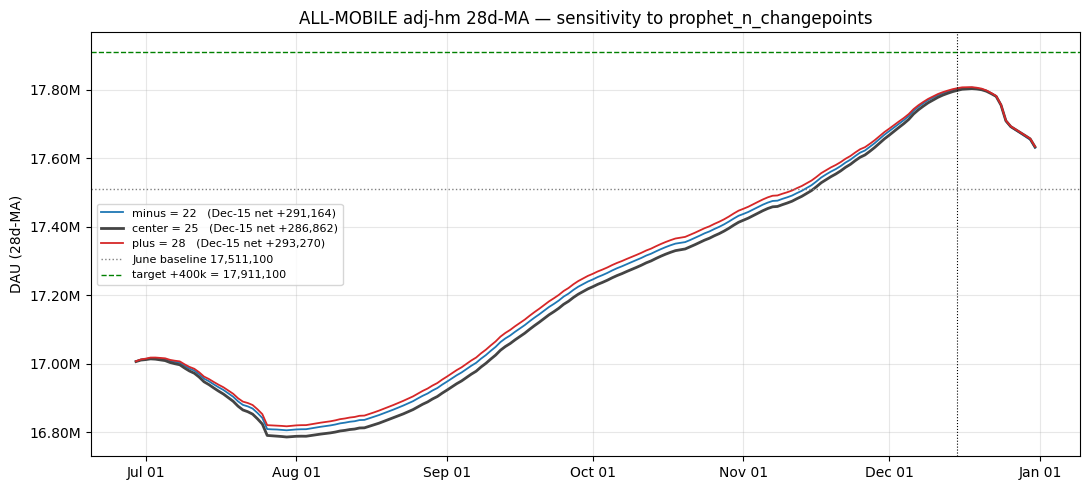

saved research/param-scans/mobile-july/plots/sensitivity_prophet_n_changepoints.png


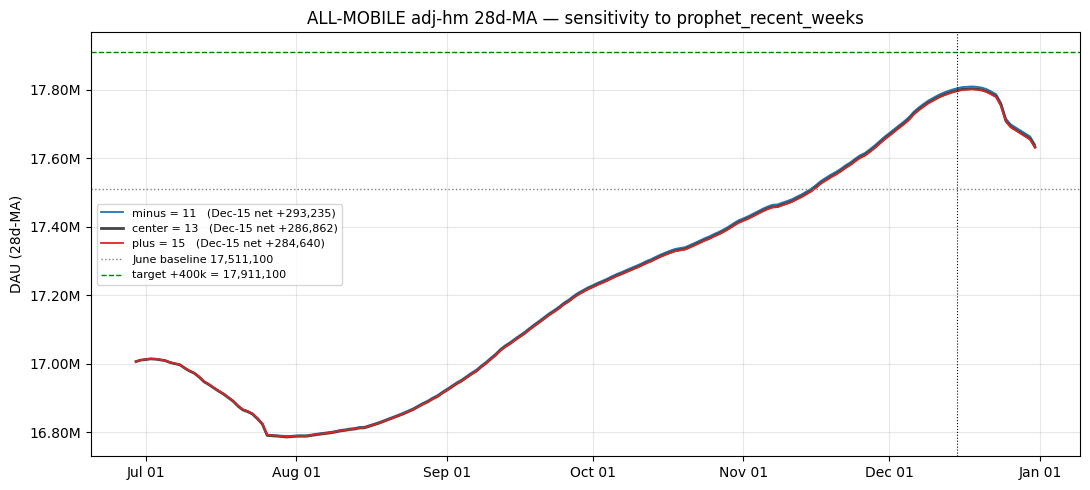

saved research/param-scans/mobile-july/plots/sensitivity_prophet_recent_weeks.png


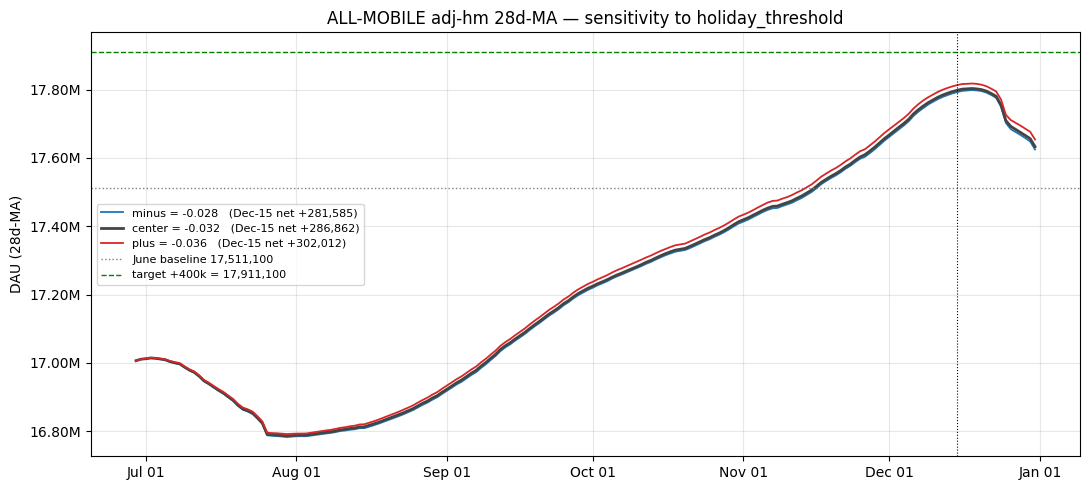

saved research/param-scans/mobile-july/plots/sensitivity_holiday_threshold.png


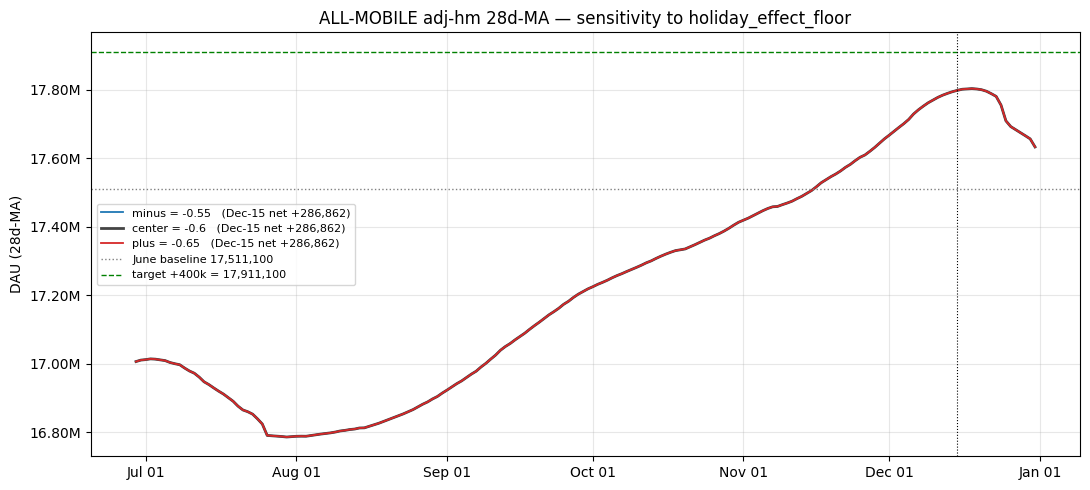

saved research/param-scans/mobile-july/plots/sensitivity_holiday_effect_floor.png


In [3]:
# [plot-per-variable]
# One figure per knob: the ALL-MOBILE adj-hm 28d-MA curve over the forecast horizon
# for {minus, center, plus}, with June baseline + target reference lines and the
# Dec-15 net annotated. Shows each knob's effect on the headline in isolation.
FC0, FC1 = FORECAST_START, pd.Timestamp("2026-12-31")
COLORS = {"minus": "#1f77b4", "center": "#444444", "plus": "#d62728"}


def _y_formatter(vals):
    span = np.nanmax(vals) - np.nanmin(vals)
    prec = 2 if span >= 2e5 else 3          # keep ticks distinguishable on narrow ranges
    return plt.FuncFormatter(lambda v, _: f"{v/1e6:.{prec}f}M")


for field, entry in RUNS.items():
    fig, ax = plt.subplots(figsize=(11, 5))
    seg_vals = []
    for direction in ("minus", "center", "plus"):
        item = entry.get(direction)
        if item is None:
            continue
        curve, score, val = item
        seg = curve.loc[FC0:FC1]
        seg_vals.append(seg.values)
        ax.plot(seg.index, seg.values, color=COLORS[direction],
                lw=2.0 if direction == "center" else 1.3,
                label=f"{direction} = {val}   (Dec-15 net {score['net_vs_june']:+,.0f})")
    ax.axhline(JUNE_BASELINE_MA28, color="gray", ls=":", lw=1.0,
               label=f"June baseline {JUNE_BASELINE_MA28:,.0f}")
    ax.axhline(TARGET_MA28, color="green", ls="--", lw=1.0,
               label=f"target +400k = {TARGET_MA28:,.0f}")
    ax.axvline(DEC15, color="k", ls=":", lw=0.8)
    ax.yaxis.set_major_formatter(_y_formatter(np.concatenate(seg_vals)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.set_title(f"ALL-MOBILE adj-hm 28d-MA — sensitivity to {field}")
    ax.set_ylabel("DAU (28d-MA)")
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    out = PLOTS_DIR / f"sensitivity_{field}.png"
    fig.savefig(out, dpi=120)
    plt.show()
    print("saved", out.relative_to(REPO))


                          param net_minus net_center net_plus span_pm_delta d_net_per_unit
           holiday_effect_floor   286,862    286,862  286,862             0             -0
         prophet_n_changepoints   291,164    286,862  293,270         2,106            351
           prophet_recent_weeks   293,235    286,862  284,640        -8,595         -2,149
              holiday_threshold   281,585    286,862  302,012        20,427     -2,553,336
prophet_changepoint_prior_scale   274,737    286,862  317,124        42,387      4,238,652
      prophet_changepoint_range   309,889    286,862  251,659       -58,229       -970,491


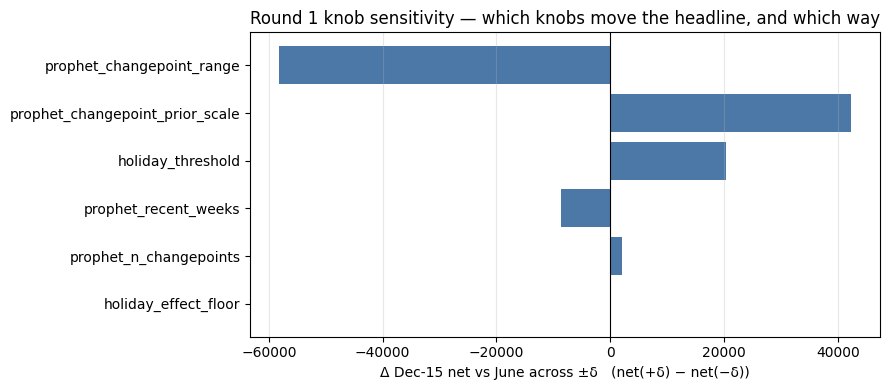

saved research/param-scans/mobile-july/plots/sensitivity_tornado.png


In [4]:
# [slope-tornado]
# Local slope per knob (central difference) + a tornado of the net span across ±δ.
rows = []
for field, entry in RUNS.items():
    if entry.get("minus") and entry.get("plus"):
        (_, s_minus, v_minus) = entry["minus"]
        (_, s_plus, v_plus) = entry["plus"]
        slope = (s_plus["net_vs_june"] - s_minus["net_vs_june"]) / (v_plus - v_minus)
        rows.append({
            "param": field,
            "net_minus": s_minus["net_vs_june"],
            "net_center": center_score["net_vs_june"],
            "net_plus": s_plus["net_vs_june"],
            "span_pm_delta": s_plus["net_vs_june"] - s_minus["net_vs_june"],
            "d_net_per_unit": slope,
        })
slopes = pd.DataFrame(rows).sort_values("span_pm_delta", key=lambda s: s.abs())
print(slopes.to_string(index=False,
      formatters={c: (lambda v: f"{v:,.0f}") for c in
                  ["net_minus", "net_center", "net_plus", "span_pm_delta", "d_net_per_unit"]}))

fig, ax = plt.subplots(figsize=(9, 4))
y = range(len(slopes))
ax.barh(list(y), slopes["span_pm_delta"].values, color="#4c78a8")
ax.set_yticks(list(y))
ax.set_yticklabels(slopes["param"])
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ Dec-15 net vs June across ±δ   (net(+δ) − net(−δ))")
ax.set_title("Round 1 knob sensitivity — which knobs move the headline, and which way")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
out = PLOTS_DIR / "sensitivity_tornado.png"
fig.savefig(out, dpi=120)
plt.show()
print("saved", out.relative_to(REPO))


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

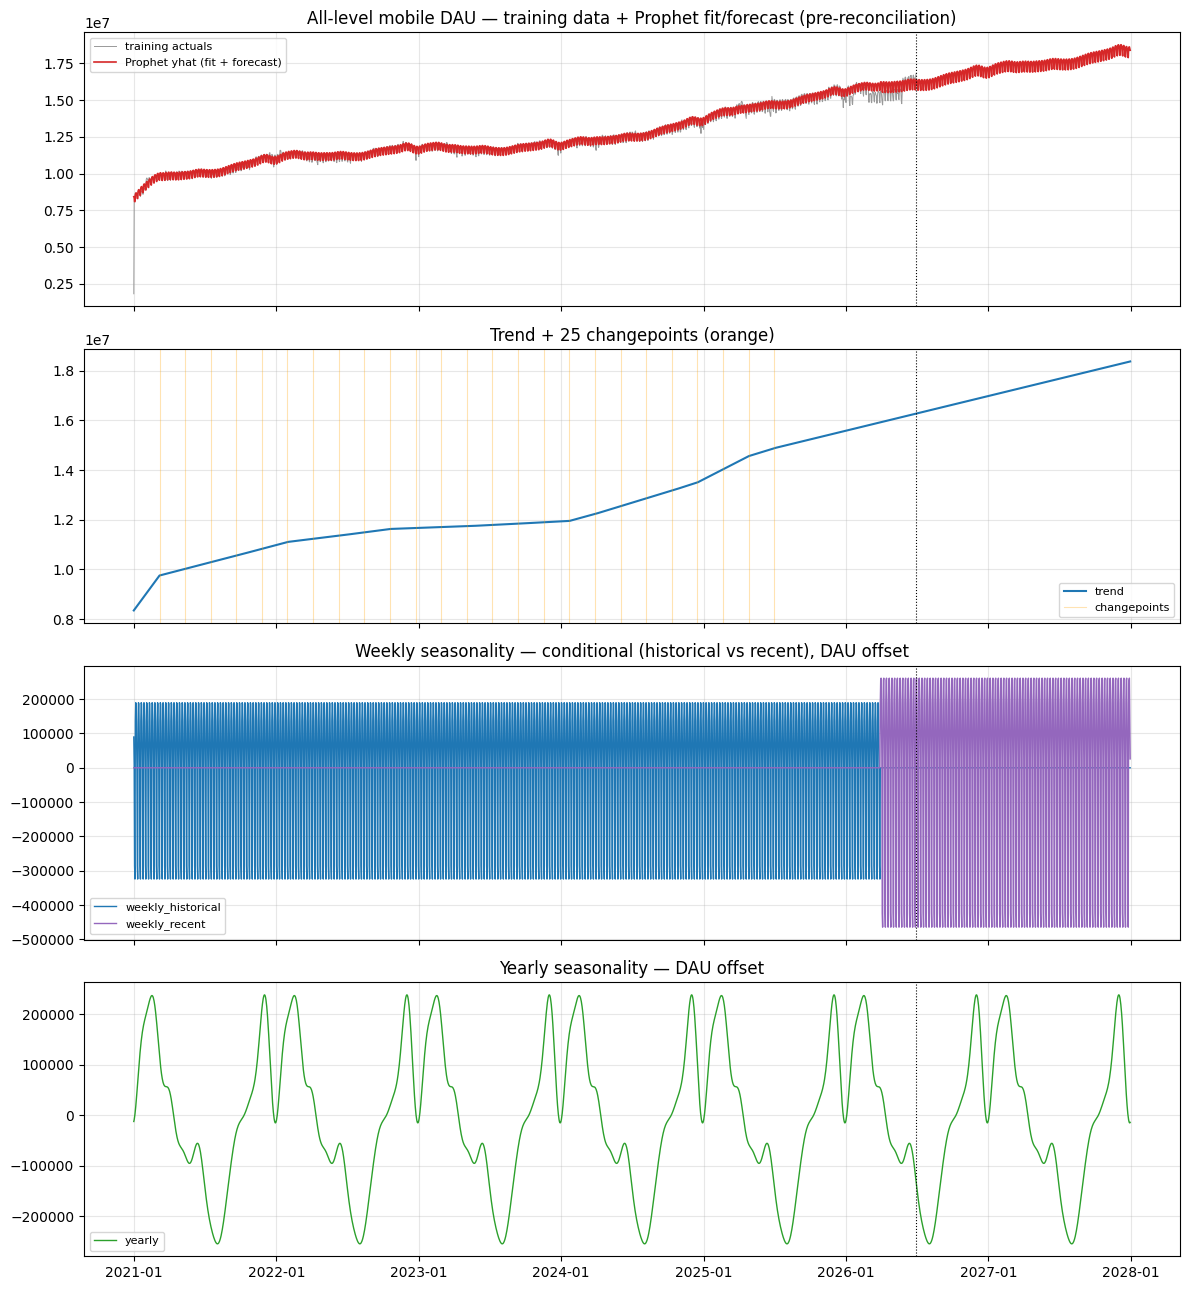

growth=linear  changepoints=25 (2021-03-07 .. 2025-07-01)
saved research/param-scans/mobile-july/plots/prophet_decomposition_mobile.png


In [5]:
# [prophet-decomposition]
# Full decomposition of the SINGLE all-level mobile Prophet (the canonical model saved
# on the top-level Mozaic). This model is linear-growth in RAW DAU space, so its
# component columns (trend / weekly_* / yearly / yhat) are already in DAU units — no
# log back-transform (that would overflow). Components are the top-level fit, before
# bottom-up reconciliation across tiles and before the marketing add-back, so yhat here
# is the structural fit, not the final reconciled ALL-MOBILE headline.
import pickle
from decompose import _build_future_df   # reused: builds ds + is_historical/is_recent conditions

CENTER_PKL = g.slug_dir_for(RESULTS_DIR, {}) / "mozaic_objects.glean_mobile.2026-06-29.pkl"
mozaic = pickle.load(open(CENTER_PKL, "rb"))["DAU"]
pm = mozaic._prophet_model
fs = pd.Timestamp(mozaic.forecast_start_date)

# Full-range prediction (history + forecast) so historical changepoints are visible.
future = _build_future_df(mozaic, pm, recent_weeks=13)
pf = pm.predict(future)
pf["ds"] = pd.to_datetime(pf["ds"])
hist = pd.DataFrame({"ds": pd.to_datetime(mozaic.historical_dates.values),
                     "actual": np.asarray(mozaic.raw_historical_data.values, dtype=float)})

fig, axes = plt.subplots(4, 1, figsize=(12, 13), sharex=True)

# Panel 1 — training data + Prophet fit/forecast (DAU space).
axes[0].plot(hist["ds"], hist["actual"], color="#999999", lw=0.7, label="training actuals")
axes[0].plot(pf["ds"], pf["yhat"], color="#d62728", lw=1.2, label="Prophet yhat (fit + forecast)")
axes[0].axvline(fs, color="k", ls=":", lw=0.8)
axes[0].set_title("All-level mobile DAU — training data + Prophet fit/forecast (pre-reconciliation)")
axes[0].legend(fontsize=8)

# Panel 2 — trend with changepoints (all historical, 2021–2025).
axes[1].plot(pf["ds"], pf["trend"], color="#1f77b4", lw=1.5, label="trend")
for i, cp in enumerate(pm.changepoints):
    axes[1].axvline(pd.Timestamp(cp), color="orange", alpha=0.30, lw=0.8,
                    label="changepoints" if i == 0 else None)
axes[1].axvline(fs, color="k", ls=":", lw=0.8)
axes[1].set_title(f"Trend + {len(pm.changepoints)} changepoints (orange)")
axes[1].legend(fontsize=8)

# Panel 3 — weekly seasonality (conditional: historical vs recent), DAU-additive.
axes[2].plot(pf["ds"], pf["weekly_historical"].fillna(0), lw=1.0, label="weekly_historical")
axes[2].plot(pf["ds"], pf["weekly_recent"].fillna(0), lw=1.0, color="#9467bd", label="weekly_recent")
axes[2].axvline(fs, color="k", ls=":", lw=0.8)
axes[2].set_title("Weekly seasonality — conditional (historical vs recent), DAU offset")
axes[2].legend(fontsize=8)

# Panel 4 — yearly seasonality, DAU-additive.
axes[3].plot(pf["ds"], pf["yearly"].fillna(0), color="#2ca02c", lw=1.0, label="yearly")
axes[3].axvline(fs, color="k", ls=":", lw=0.8)
axes[3].set_title("Yearly seasonality — DAU offset")
axes[3].legend(fontsize=8)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
out = PLOTS_DIR / "prophet_decomposition_mobile.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"growth={pm.growth}  changepoints={len(pm.changepoints)} "
      f"({pm.changepoints.min().date()} .. {pm.changepoints.max().date()})")
print("saved", out.relative_to(REPO))


## Round 2 — wider sweeps + gradient-guessed configs

Round 1 said the three active knobs are `changepoint_range` (↓ raises net), `changepoint_prior_scale`
(↑ raises net), and `holiday_threshold` (more negative raises net); `recent_weeks` is weak and
`holiday_effect_floor` is inert. Round 2 ranges those knobs further in the favorable direction
(cpr only downward, so changepoints stay out of the last ~2 months), adds larger `recent_weeks`
steps, and tests gradient-extrapolated single-knob targets plus two combined configs. Because these
knobs are non-linear, the extrapolations are guesses — the response curves below show the real shape.


In [6]:
# [round2-load]
# Gather all single-knob runs (center + round1 ±δ + round2 wider) per knob, so we can
# draw the true (non-linear) response curve of Dec-15 net vs each knob, and load the
# round-2 combined configs for the ranking.
R2_CSV = REPO / "research/param-scans/mobile-july/round2_results.csv"
r1 = pd.read_csv(REPO / "research/param-scans/mobile-july/round1_results.csv")
r2 = pd.read_csv(R2_CSV)

CENTER = {
    "prophet_changepoint_prior_scale": 0.02,
    "prophet_changepoint_range": 0.82,
    "holiday_threshold": -0.032,
    "prophet_recent_weeks": 13,
}
center_net = float(r1.loc[r1.param == "(center)", "net_vs_june"].iloc[0])

# Per-knob response points: {knob: DataFrame[value, net_vs_june]} across both rounds + center.
response = {}
for knob, cval in CENTER.items():
    pts = [(cval, center_net)]
    for _, row in r1[r1.param == knob].iterrows():
        pts.append((float(row["value"]), float(row["net_vs_june"])))
    for _, row in r2[(r2["kind"] == "single") & (r2["label"].str.startswith(knob + "="))].iterrows():
        pts.append((float(row["label"].split("=")[1]), float(row["net_vs_june"])))
    response[knob] = (pd.DataFrame(pts, columns=["value", "net"])
                      .drop_duplicates("value").sort_values("value").reset_index(drop=True))

combined = r2[r2["kind"] == "combined"].copy()
print("center net:", f"{center_net:+,.0f}", " target +400,000")
for knob, dfk in response.items():
    print(f"{knob}: {len(dfk)} points  net range {dfk.net.min():+,.0f}..{dfk.net.max():+,.0f}")
print("combined:", combined[["label", "net_vs_june", "gap_to_target"]].to_dict("records"))


center net: +286,862  target +400,000
prophet_changepoint_prior_scale: 7 points  net range +274,737..+317,124
prophet_changepoint_range: 6 points  net range +251,659..+644,375
holiday_threshold: 6 points  net range +281,585..+302,012
prophet_recent_weeks: 7 points  net range +282,893..+312,061
combined: [{'label': 'grad_moderate', 'net_vs_june': 407639.04923025146, 'gap_to_target': -7639.049230251461}, {'label': 'grad_even', 'net_vs_june': 324503.51969542727, 'gap_to_target': 75496.48030457273}]


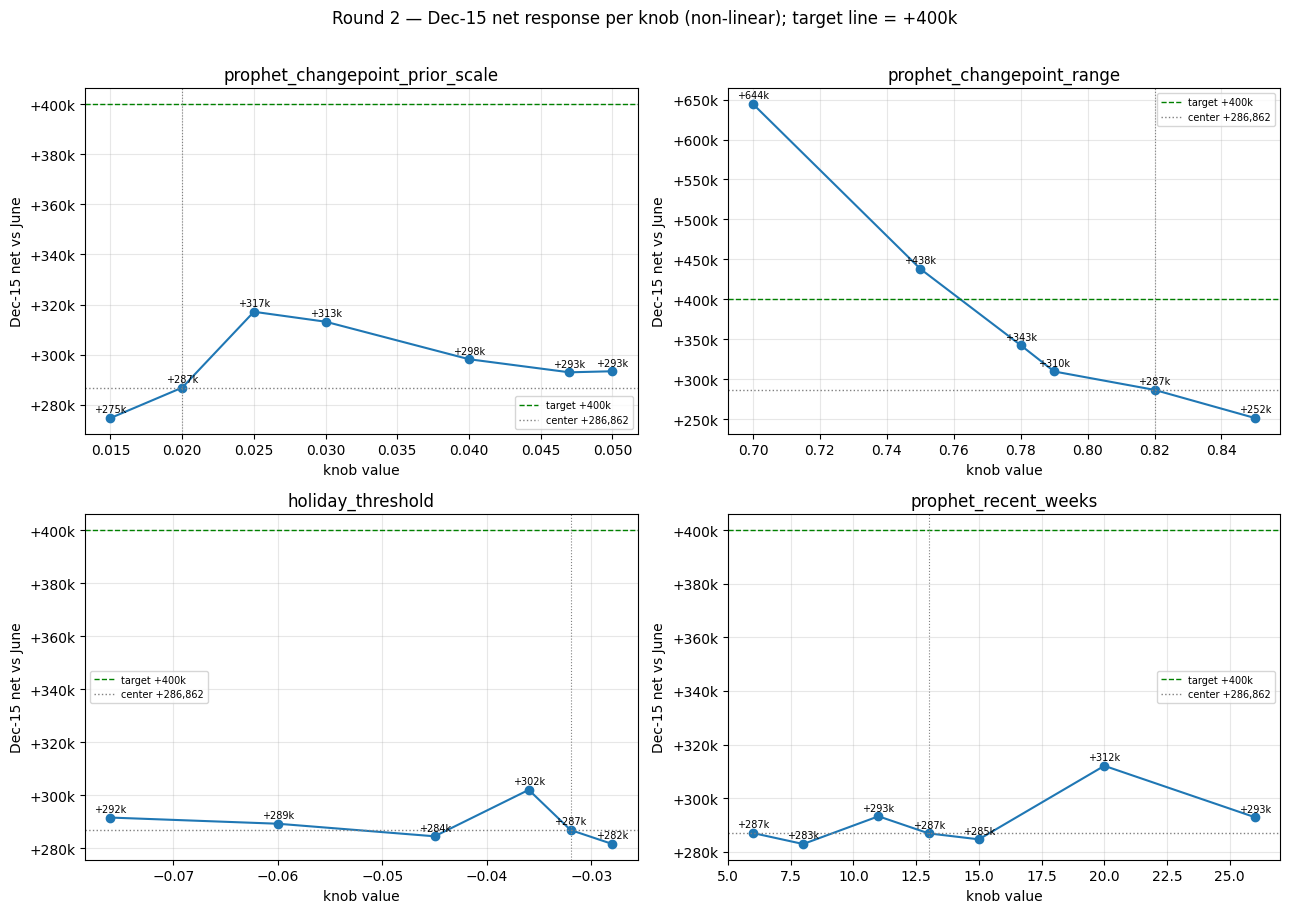

saved research/param-scans/mobile-july/plots/round2_response_curves.png


In [7]:
# [round2-response-curves]
# True (non-linear) response of Dec-15 net vs June for each swept knob, with the
# +400k target line. Where a curve crosses the target line is that knob's solo answer.
TARGET_NET = 400_000.0
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (knob, dfk) in zip(axes.ravel(), response.items()):
    ax.plot(dfk["value"], dfk["net"], "o-", color="#1f77b4", lw=1.5)
    ax.axhline(TARGET_NET, color="green", ls="--", lw=1, label="target +400k")
    ax.axhline(center_net, color="gray", ls=":", lw=1, label=f"center {center_net:+,.0f}")
    ax.axvline(CENTER[knob], color="gray", ls=":", lw=0.8)
    for _, r in dfk.iterrows():
        ax.annotate(f"{r['net']/1e3:+.0f}k", (r["value"], r["net"]),
                    fontsize=7, xytext=(0, 4), textcoords="offset points", ha="center")
    ax.set_title(knob)
    ax.set_xlabel("knob value")
    ax.set_ylabel("Dec-15 net vs June")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e3:+.0f}k"))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
fig.suptitle("Round 2 — Dec-15 net response per knob (non-linear); target line = +400k", y=1.01)
fig.tight_layout()
out = PLOTS_DIR / "round2_response_curves.png"
fig.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print("saved", out.relative_to(REPO))


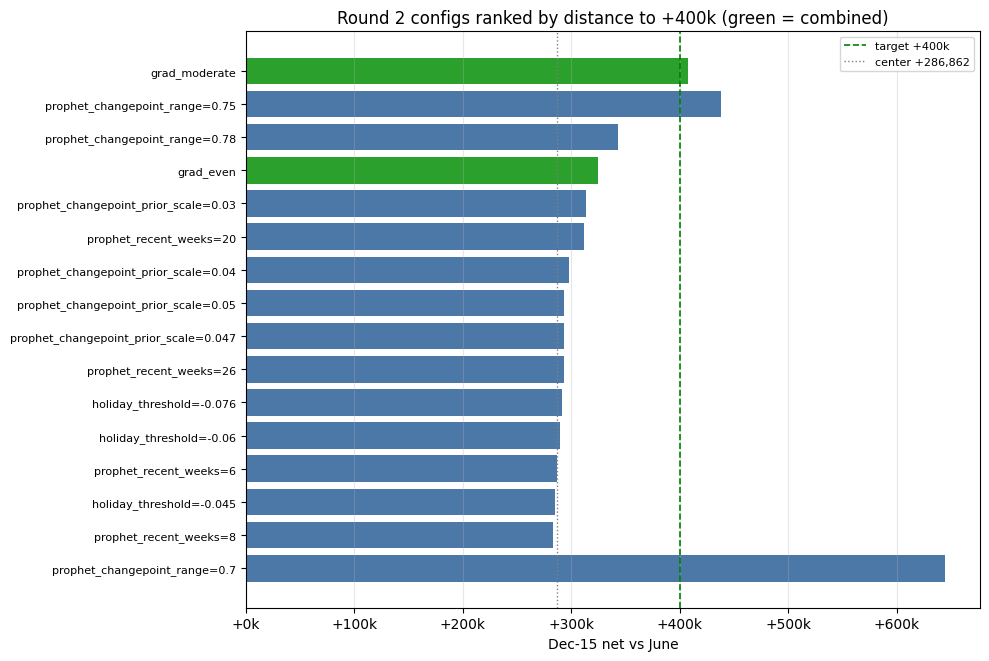

closest configs to +400k:
                               label     kind   net_vs_june  gap_to_target
                       grad_moderate combined 407639.049230   -7639.049230
      prophet_changepoint_range=0.75   single 438221.276276  -38221.276276
      prophet_changepoint_range=0.78   single 342767.311693   57232.688307
                           grad_even combined 324503.519695   75496.480305
prophet_changepoint_prior_scale=0.03   single 313160.159359   86839.840641
             prophet_recent_weeks=20   single 312060.617796   87939.382204
saved research/param-scans/mobile-july/plots/round2_ranking.png


In [8]:
# [round2-ranking]
# All round-2 configs ranked by distance to the +400k target (net vs June).
rank = r2.sort_values("abs_gap").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, max(4, 0.42 * len(rank))))
y = range(len(rank))
colors = ["#2ca02c" if k == "combined" else "#4c78a8" for k in rank["kind"]]
ax.barh(list(y), rank["net_vs_june"].values, color=colors)
ax.axvline(400_000, color="green", ls="--", lw=1.2, label="target +400k")
ax.axvline(center_net, color="gray", ls=":", lw=1, label=f"center {center_net:+,.0f}")
ax.set_yticks(list(y))
ax.set_yticklabels(rank["label"], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Dec-15 net vs June")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e3:+.0f}k"))
ax.set_title("Round 2 configs ranked by distance to +400k (green = combined)")
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
out = PLOTS_DIR / "round2_ranking.png"
fig.savefig(out, dpi=120)
plt.show()
print("closest configs to +400k:")
print(rank[["label", "kind", "net_vs_june", "gap_to_target"]].head(6).to_string(index=False))
print("saved", out.relative_to(REPO))


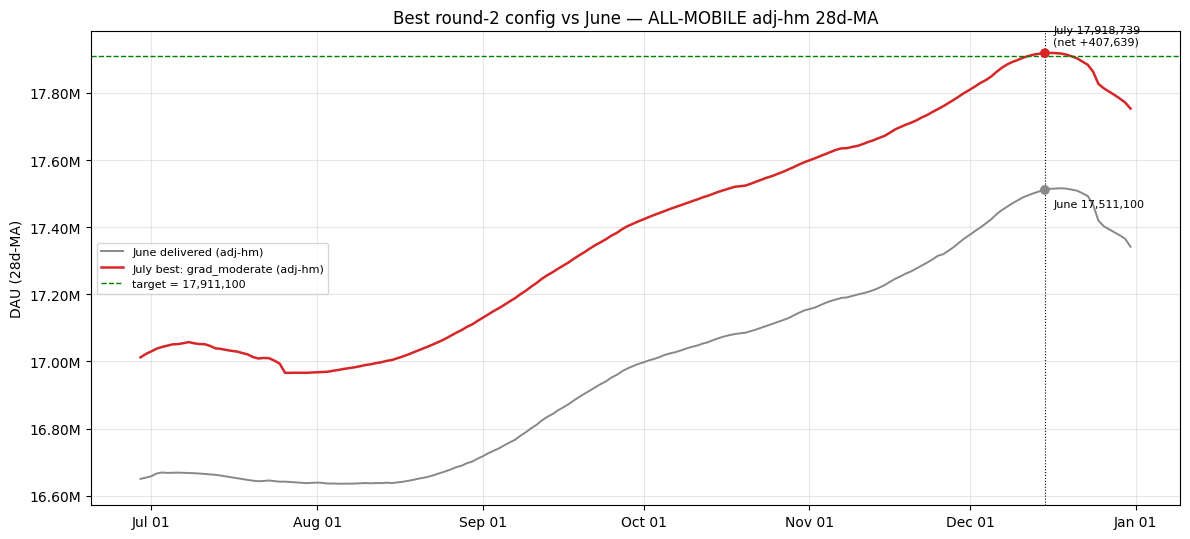

best config: grad_moderate  net +407,639  gap -7,639
saved research/param-scans/mobile-july/plots/round2_best_vs_june.png


In [9]:
# [round2-best-vs-june]
# Full-horizon curve of the round-2 config closest to +400k, overlaid on the June
# delivered mobile curve (both plus-Iran ALL-MOBILE 28d-MA), with the Dec-15 markers.
best = r2.sort_values("abs_gap").iloc[0]
best_pq = g.adjm_parquet_for(RESULTS_DIR / best["slug"])
best_curve = apply_headwind(forecast_display_ma(all_mobile_daily(pd.read_parquet(best_pq))))

june = (pd.read_csv(REPO / "data-official/2026-06/csv/june_canonical_curves.csv", parse_dates=["date"])
        .set_index("date")["mobile_current_june_plus_iran"].sort_index())

FC0, FC1 = FORECAST_START, pd.Timestamp("2026-12-31")
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(june.loc[FC0:FC1].index, june.loc[FC0:FC1].values, color="#888", lw=1.4, label="June delivered (adj-hm)")
ax.plot(best_curve.loc[FC0:FC1].index, best_curve.loc[FC0:FC1].values, color="#d62728", lw=1.8,
        label=f"July best: {best['label']} (adj-hm)")
ax.axhline(TARGET_MA28, color="green", ls="--", lw=1, label=f"target = {TARGET_MA28:,.0f}")
ax.axvline(DEC15, color="k", ls=":", lw=0.8)
ax.scatter([DEC15, DEC15], [june.loc[DEC15], best_curve.loc[DEC15]], color=["#888", "#d62728"], zorder=5)
ax.annotate(f"June {june.loc[DEC15]:,.0f}", (DEC15, june.loc[DEC15]), fontsize=8,
            xytext=(6, -12), textcoords="offset points")
ax.annotate(f"July {best_curve.loc[DEC15]:,.0f}\n(net {best['net_vs_june']:+,.0f})",
            (DEC15, best_curve.loc[DEC15]), fontsize=8, xytext=(6, 6), textcoords="offset points")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("Best round-2 config vs June — ALL-MOBILE adj-hm 28d-MA")
ax.set_ylabel("DAU (28d-MA)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
out = PLOTS_DIR / "round2_best_vs_june.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"best config: {best['label']}  net {best['net_vs_june']:+,.0f}  gap {best['gap_to_target']:+,.0f}")
print("saved", out.relative_to(REPO))


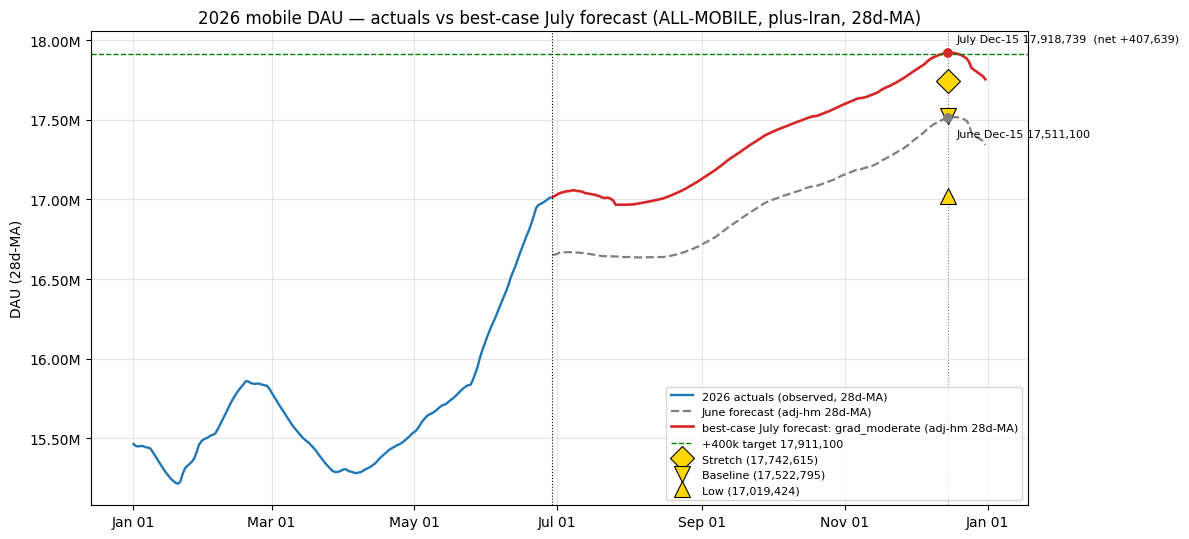

actuals through 2026-06-28  |  Dec-15 forecast 17,918,739
saved research/param-scans/mobile-july/plots/actuals_vs_bestcase_2026.png


In [10]:
# [actuals-vs-bestcase]
# 2026 observed mobile DAU vs the best-case July forecast, on shared axes.
# "Best-case" = the round-2 config closest to +400k (currently grad_moderate).
# Both are ALL-MOBILE, plus-Iran, 28d-MA. Actuals are the observed training series
# (dates < forecast_start) from the raw no-marketing July combined parquet; the
# Mar–May dip is the real Iran shutdown (the forecast trains on the counterfactual fill).
best = r2.sort_values("abs_gap").iloc[0]
best_curve = apply_headwind(forecast_display_ma(
    all_mobile_daily(pd.read_parquet(g.adjm_parquet_for(RESULTS_DIR / best["slug"])))))

raw_daily = all_mobile_daily(pd.read_parquet(
    REPO / "data-official/2026-07/mozaic_daily_forecast.2026-06-29.gm+ld-D+NP.parquet"))
actuals_ma = raw_daily[raw_daily.index < FORECAST_START].rolling(28).mean()

# June delivered forecast (adj-hm 28d-MA) for the actuals-vs-June-vs-July story.
june = (pd.read_csv(REPO / "data-official/2026-06/csv/june_canonical_curves.csv", parse_dates=["date"])
        .set_index("date")["mobile_current_june_plus_iran"].sort_index())

Y0, Y1 = pd.Timestamp("2026-01-01"), pd.Timestamp("2026-12-31")
a = actuals_ma.loc[Y0:Y1]
f = best_curve.loc[FORECAST_START:Y1]
j = june.loc[FORECAST_START:Y1]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(a.index, a.values, color="#1f77b4", lw=1.7, label="2026 actuals (observed, 28d-MA)")
ax.plot(j.index, j.values, color="#7f7f7f", ls="--", lw=1.6, label="June forecast (adj-hm 28d-MA)")
ax.plot(f.index, f.values, color="#d62728", lw=1.9,
        label=f"best-case July forecast: {best['label']} (adj-hm 28d-MA)")
ax.axhline(TARGET_MA28, color="green", ls="--", lw=1, label=f"+400k target {TARGET_MA28:,.0f}")
ax.axvline(FORECAST_START, color="k", ls=":", lw=0.8)
ax.axvline(DEC15, color="gray", ls=":", lw=0.8)

# Three stakeholder Dec-15 mobile benchmarks (reused from June), same style as the
# canonical notebook (data-official/2026-07/july_canonical_v2026-06-29.ipynb).
STAKEHOLDER_MOBILE_LOW = 17_019_424
STAKEHOLDER_MOBILE_BASELINE = 17_522_795
STAKEHOLDER_MOBILE_STRETCH = 17_742_615
for value, marker, label in [
    (STAKEHOLDER_MOBILE_STRETCH, "D", "Stretch"),
    (STAKEHOLDER_MOBILE_BASELINE, "v", "Baseline"),
    (STAKEHOLDER_MOBILE_LOW, "^", "Low"),
]:
    ax.plot(DEC15, value, marker=marker, color="gold", markersize=12,
            markeredgecolor="black", markeredgewidth=0.8, linestyle="None",
            label=f"{label} ({value:,})")
ax.scatter([DEC15, DEC15], [best_curve.loc[DEC15], june.loc[DEC15]],
           color=["#d62728", "#7f7f7f"], zorder=5)
ax.annotate(f"July Dec-15 {best_curve.loc[DEC15]:,.0f}  (net {best['net_vs_june']:+,.0f})",
            (DEC15, best_curve.loc[DEC15]), fontsize=8, xytext=(6, 8), textcoords="offset points")
ax.annotate(f"June Dec-15 {june.loc[DEC15]:,.0f}",
            (DEC15, june.loc[DEC15]), fontsize=8, xytext=(6, -14), textcoords="offset points")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("2026 mobile DAU — actuals vs best-case July forecast (ALL-MOBILE, plus-Iran, 28d-MA)")
ax.set_ylabel("DAU (28d-MA)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
out = PLOTS_DIR / "actuals_vs_bestcase_2026.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"actuals through {a.dropna().index.max().date()}  |  Dec-15 forecast {best_curve.loc[DEC15]:,.0f}")
print("saved", out.relative_to(REPO))


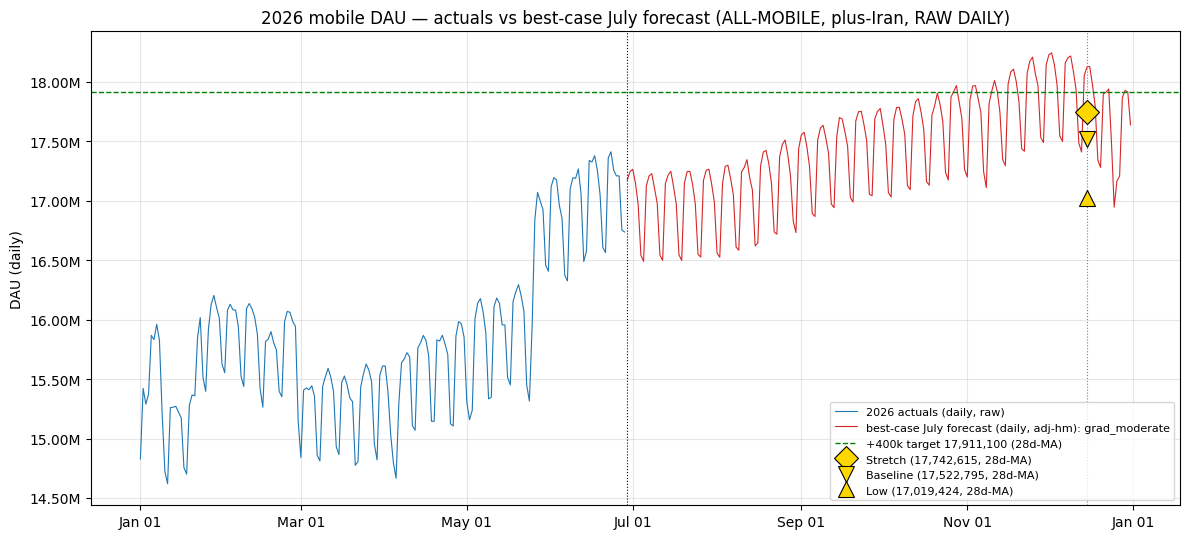

actuals daily through 2026-06-28  |  Dec-15 forecast daily 18,126,332
saved research/param-scans/mobile-july/plots/actuals_vs_bestcase_2026_daily.png


In [11]:
# [actuals-vs-bestcase-daily]
# Same comparison as above but RAW DAILY (no 28-day MA) — shows the weekday/weekend
# cycle in both observed and forecast. Forecast = best-case adj-m daily + the daily
# headwind ramp. June is omitted here (only its MA curve is available, not daily).
best = r2.sort_values("abs_gap").iloc[0]
best_daily_full = all_mobile_daily(pd.read_parquet(g.adjm_parquet_for(RESULTS_DIR / best["slug"])))
best_daily_hm = apply_headwind(best_daily_full)   # adds the daily ramp on forecast dates

raw_daily = all_mobile_daily(pd.read_parquet(
    REPO / "data-official/2026-07/mozaic_daily_forecast.2026-06-29.gm+ld-D+NP.parquet"))

Y0, Y1 = pd.Timestamp("2026-01-01"), pd.Timestamp("2026-12-31")
a_d = raw_daily[(raw_daily.index >= Y0) & (raw_daily.index < FORECAST_START)]
f_d = best_daily_hm[(best_daily_hm.index >= FORECAST_START) & (best_daily_hm.index <= Y1)]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(a_d.index, a_d.values, color="#1f77b4", lw=0.8, label="2026 actuals (daily, raw)")
ax.plot(f_d.index, f_d.values, color="#d62728", lw=0.8,
        label=f"best-case July forecast (daily, adj-hm): {best['label']}")
ax.axhline(TARGET_MA28, color="green", ls="--", lw=1, label=f"+400k target {TARGET_MA28:,.0f} (28d-MA)")
ax.axvline(FORECAST_START, color="k", ls=":", lw=0.8)
ax.axvline(DEC15, color="gray", ls=":", lw=0.8)

# Stakeholder Dec-15 benchmarks are 28d-MA levels — shown here as reference lines.
STAKEHOLDER_MOBILE_LOW = 17_019_424
STAKEHOLDER_MOBILE_BASELINE = 17_522_795
STAKEHOLDER_MOBILE_STRETCH = 17_742_615
for value, marker, label in [
    (STAKEHOLDER_MOBILE_STRETCH, "D", "Stretch"),
    (STAKEHOLDER_MOBILE_BASELINE, "v", "Baseline"),
    (STAKEHOLDER_MOBILE_LOW, "^", "Low"),
]:
    ax.plot(DEC15, value, marker=marker, color="gold", markersize=12,
            markeredgecolor="black", markeredgewidth=0.8, linestyle="None",
            label=f"{label} ({value:,}, 28d-MA)")

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("2026 mobile DAU — actuals vs best-case July forecast (ALL-MOBILE, plus-Iran, RAW DAILY)")
ax.set_ylabel("DAU (daily)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
out = PLOTS_DIR / "actuals_vs_bestcase_2026_daily.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"actuals daily through {a_d.index.max().date()}  |  Dec-15 forecast daily {best_daily_hm.loc[DEC15]:,.0f}")
print("saved", out.relative_to(REPO))


## Decisions, implications, and consequences

### What we were solving for
Land the July mobile forecast's **ALL-MOBILE, plus-Iran, Dec-15 28-day-MA** at **June + 400,000 = 17,911,100** (June baseline 17,511,100), measured with the marketing tailwind (`m`) and the headwind (`h`) both applied. The baseline is read directly from June's delivered canonical curve (`mobile_current_june_plus_iran`), which is already a seam-matched `display_ma`, so both sides are compared on the same MA definition. At the Dec-15 far horizon that MA equals a plain forecast-only `rolling(28).mean()`.

### Choices we made

1. **Held the adjustments fixed; searched only model parameters.** The marketing tailwind (`m`, the June-anchored *total* lift model) and the headwind (`h`, a linear ramp reaching −27,162 mobile DAU at the Dec-15 anchor) were treated as given. The headwind is applied with the production convention — the **full daily anchor (−27,162) at Dec-15**, not the ramp's 28-day average. All tuning happened in `MobileModelConfig`.

2. **Probed locally before ranging (rounds 1 → 2).** Round 1 was a one-at-a-time central-difference slope probe (six knobs, small ±δ). Round 2 ranged the knobs that mattered further in the favorable direction, added larger `recent_weeks` steps, and tested two gradient-extrapolated combined configs.

3. **Respected one hard constraint: no changepoints in the last ~2 months.** `changepoint_range` was only ranged *downward* (≤ 0.82), which confines Prophet's changepoints to earlier history — the last one stays around mid-2025, nowhere near the forecast seam.

4. **Chosen model — `grad_moderate`:** `changepoint_prior_scale = 0.035`, `changepoint_range = 0.75`, `holiday_threshold = −0.055` (all other knobs at June defaults: `n_changepoints = 25`, `recent_weeks = 13`, `holiday_effect_floor = −0.6`). It lands **Dec-15 = 17,918,739, net +407,639** — ~7.6k (0.04%) above the +400k target.

### What the search taught us
- **`changepoint_range` is the only strong, monotonic lever, and it is steeply non-linear.** Net vs June went 0.85 → +251,659, 0.82 → +286,862, 0.79 → +309,889, 0.78 → +342,767, 0.75 → **+438,221**, 0.70 → **+644,375**. The response *accelerates* as cpr drops.
- **`changepoint_prior_scale` is non-monotonic** — it peaks (~+313–317k) near 0.025–0.03 and *declines* for larger values. The linear gradient guess (0.047) was wrong because of this hump.
- **`holiday_threshold` is non-monotonic and weak** (a small +15k bump at −0.036, no gain beyond).
- **`recent_weeks` is noise** (±15k, no trend) and **`holiday_effect_floor` is inert** (mobile holiday effects never reach the −0.6 floor).

### Implications and consequences

- **This is a deliberate retune, not "params stable."** cps moved 0.02 → 0.035, cpr 0.82 → 0.75, threshold −0.032 → −0.055. July mobile is no longer on the June defaults; that is a conscious choice to hit the target and should be recorded as such.
- **The lift comes from the trend, not the adjustments.** Lowering cpr makes Prophet extrapolate the *recent* up-slope (post-Iran-recovery rebound + the marketing ramp) more aggressively; higher cps adds trend flexibility. The forecast therefore rides the steep spring/summer surge forward. Most of the +400k vs June is this higher recent-actuals anchor plus the retuned trend — the `m`/`h` adjustments net small at Dec-15.
- **The config sits on the fragile part of the curve.** Because cpr = 0.75 is in the steep, accelerating region, a 0.01 change in cpr swings Dec-15 by tens of thousands, and the same config on a *future* data pull could move materially. The landing is real but sensitive — expect to re-tune on the next run rather than treat cpr = 0.75 as fixed.
- **Extrapolation risk.** If the recent surge is partly transient (the Iran recovery overshot pre-shutdown levels by ~36% at the seam; the marketing ramp may plateau), extrapolating it forward risks running hot versus realized DAU. This is a forecasting-judgment risk, not a modeling bug — flagged so it's a known, owned assumption.
- **We are above the stakeholder bar.** The +400k target (17,911,100) and this model (17,918,739) both **exceed the stakeholder Stretch benchmark (17,742,615)** by ~170k, and sit well above Baseline (17,522,795) and Low (17,019,424). Hitting +400k is a more aggressive outcome than the stated stakeholder goals.
- **A simpler alternative exists.** A single-knob **cpr ≈ 0.76** (all else at June defaults) also lands ≈ +400k and is easier to explain and defend than moving three knobs at once. `grad_moderate` was adopted because it already landed on target; if interpretability/defensibility matters more than the ~7.6k overshoot, the single-knob config is the cleaner choice.
